Choosing the blur at scale
==========================

**When to use:** before you fix ``blur``. It is the length scale below which the transport is smoothed out:
eps = blur^2 for the squared cost. A smaller blur resolves finer structure and costs more time.

**What you will see:** on 100,000 points, how the displacement field changes with the blur and how the
entropic bias pulls the points inward unless ``debias=True``; a translated cloud whose exact debiased loss is
known at every blur; and how the time of a solve grows as the blur shrinks.

Source: [plot_blur.py](plot_blur.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/getting_started/plot_blur.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/getting_started/plot_blur.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import (SOURCE, TARGET, arrows, cloud, dense_size, fit_limits, images_dir, require_cuda,  # noqa: E402
                       save, small_multiples, subsample, table, timed)

device = require_cuda()
torch.manual_seed(0)
# Every solve uses ``autotune=False``: the basics example explains why.
n = m = 100_000
x = 0.25 * torch.randn(n, 2, device=device) + torch.tensor([-0.8, 0.0], device=device)
theta = 1.2 + 2.6 * torch.rand(m, device=device)
y = torch.stack([0.6 + 0.8 * torch.cos(theta), 0.8 * torch.sin(theta)], dim=1)
y = y + 0.04 * torch.randn(m, 2, device=device)
a = torch.full((n,), 1.0 / n, device=device)
b = torch.full((m,), 1.0 / m, device=device)
print(dense_size(n, m))


def displacement(blur, debias):
    """-grad_x loss / a: where each source point is pushed (half cost)."""
    loss = SamplesLoss(blur=blur, half_cost=True, debias=debias, backend="symmetric", autotune=False)
    z = x.clone().requires_grad_(True)
    grad, = torch.autograd.grad(loss(a, z, b, y), z)
    return -grad / a[:, None]

The displacement field at four blurs
------------------------------------
At a small blur each point is pushed to the part of the arc it is matched with. As the blur grows, the plan
spreads each point over more of the target. Without debiasing (top row) the arrows then converge on the middle
of the target, so a flow would shrink the cloud; the debiased gradient (bottom row) subtracts the cloud's
transport onto itself and keeps its spread. Arrows for 100 random points; all panels share their limits.

In [ ]:
blurs = [0.02, 0.1, 0.3, 1.0]
idx = subsample(n, 100, device=device)
fields = {(blur, debias): displacement(blur, debias)[idx] for blur in blurs for debias in (False, True)}
tips = torch.cat([x[idx] + v for v in fields.values()])
span = torch.cat([x, y, tips]).amax(dim=0) - torch.cat([x, y, tips]).amin(dim=0)
fig, axes = small_multiples(2, len(blurs), size=3.2, aspect=(span[1] / span[0]).item())
for col, blur in enumerate(blurs):
    for row, debias in enumerate([False, True]):
        ax = axes[row, col]
        cloud(ax, y, TARGET)
        cloud(ax, x, SOURCE)
        arrows(ax, x[idx], fields[blur, debias])
        fit_limits(ax, x, y, tips)
        ax.set_title(f"{'S_eps' if debias else 'OT_eps'}, blur = {blur}", fontsize=10)
save(fig, images_dir(__file__), "blur_maps")

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/blur_maps.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

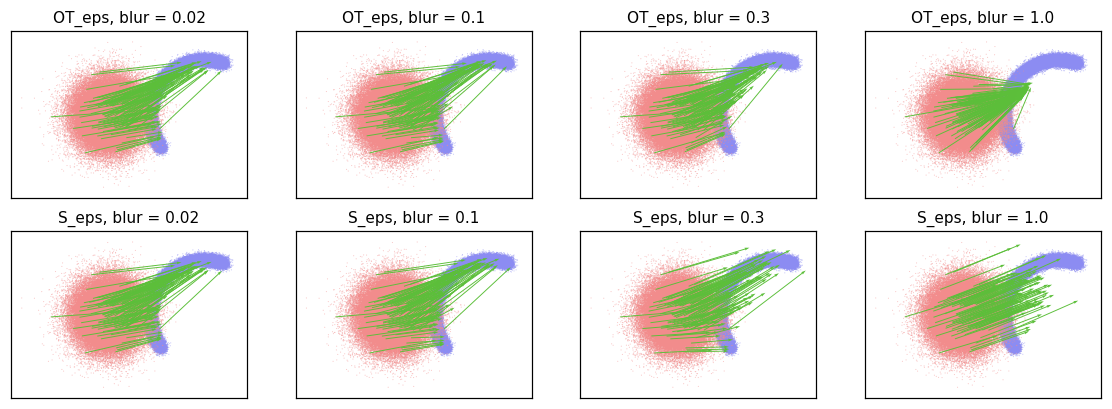

A case with a known answer
--------------------------
Translate a cloud by t. For the squared cost the entropic OT cost is then OT_eps(x, x) + |t|^2 / 2, where the
entropic bias OT_eps(x, x) grows with the blur. The debiased divergence removes it exactly, so S_eps equals
|t|^2 / 2 at every blur. The table compares this identity with the computed loss. Default TF32 rounds the
centred coordinates before evaluating costs; ``allow_tf32=False`` avoids that coordinate displacement.

In [ ]:
t = torch.tensor([0.6, 0.3], device=device)
x2 = torch.rand(n, 2, device=device)
y2 = x2 + t
exact = 0.5 * float(t @ t)
grid = torch.logspace(-2, 0.3, 10).tolist()
s_values, ot_values = [], []
for blur in grid:
    debiased = SamplesLoss(blur=blur, half_cost=True, debias=True, backend="symmetric", autotune=False)
    biased = SamplesLoss(blur=blur, half_cost=True, debias=False, backend="symmetric", autotune=False)
    s_values.append(debiased(x2, y2).item())
    ot_values.append(biased(x2, y2).item())
    print(f"blur {blur:7.4f}   S_eps - |t|^2/2 = {s_values[-1] - exact:+.2e}   "
          f"OT_eps - |t|^2/2 = {ot_values[-1] - exact:+.2e}")

fig, ax = plt.subplots(figsize=(5.6, 4.4))
table(ax, ["blur", "S_eps - |t|^2/2", "OT_eps - |t|^2/2"],
      [[f"{blur:.3g}", f"{s - exact:+.1e}", f"{ot - exact:+.1e}"] for blur, s, ot in zip(grid, s_values, ot_values)],
      title=f"cloud translated by t, |t|^2/2 = {exact:.3f}")
save(fig, images_dir(__file__), "blur_translation")

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/getting_started/images/blur_translation.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

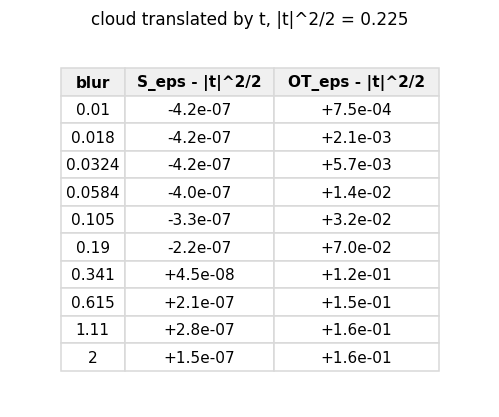

How small should the blur be?
-----------------------------
Every halving of the blur lengthens the annealing schedule, which goes from the squared diagonal of the data's
bounding box down to blur^2, shrinking eps by a factor scaling^2 per step. Compare the blur with the spacing
between points and the size of the data, and with the time a solve takes.

In [ ]:
sampled_y = y[subsample(m, 1000, seed=1, device=device)]
spacing = torch.cdist(sampled_y, y).topk(2, largest=False).values[:, 1].median().item()
both = torch.cat([x, y])
size = (both.max(dim=0).values - both.min(dim=0).values).norm().item()
print(f"median nearest-neighbour spacing of y: {spacing:.4f}; bounding-box diagonal: {size:.2f}")
for blur in [0.005, 0.02, 0.1, 0.3]:
    loss = SamplesLoss(blur=blur, half_cost=True, debias=True, backend="symmetric", autotune=False)
    timed(f"S_eps at blur {blur:5.3f} = {blur / spacing:6.1f} spacings", lambda: loss(a, x, b, y))
plt.show()